In [ ]:
%load_ext autoreload
%autoreload 2
from dataclasses import replace
from rankers.config import Config
from rankers.simulate import run, run_replicates, run_replicates_and_save_all_trajectories
import numpy as np
import matplotlib.pyplot as plt

base = Config(
    n=500,
    k=32,
    p_rewire=0.01,

    n_claims=200,
    claim_scheme="disinfo",
    llr_mag=1.0,

    repertoire_seed_size=5,
    belief_std=0.5,

    history_window=1,
    n_surfaced=1,
    ranker="baseline",
    receiver="neighbors",

    biases=("baseline",),

    n_steps=8000,
    record_every=1,
    n_tracked=50,
    seed=41,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
n_disinfo_values = [0, 10]

sweep = run_ndisinfo_sweep(base, n_disinfo_values, n_reps=20)

Running n_disinfo = 0 ...
Running n_disinfo = 10 ...


In [8]:
n_disinfo_values2 = [1, 2, 4, 8, 16, 32, 64]

sweep2 = run_ndisinfo_sweep(base, n_disinfo_values2, n_reps=20)

Running n_disinfo = 1 ...
Running n_disinfo = 2 ...
Running n_disinfo = 4 ...
Running n_disinfo = 8 ...
Running n_disinfo = 16 ...
Running n_disinfo = 32 ...
Running n_disinfo = 64 ...


In [10]:
n_disinfo_values_all = np.concatenate((n_disinfo_values, n_disinfo_values2))
sweep_all = {**sweep, **sweep2}

In [14]:
mean_by_ndisinfo = {nd: sweep_all[nd]["trajectories"].mean(axis=2) for nd in sweep_all}

In [15]:
mean_by_ndisinfo

{0: array([[-0.126, -0.088, -0.038, ..., -0.006, -0.006, -0.006],
        [ 0.104,  0.144,  0.128, ..., -0.002, -0.002, -0.002],
        [-0.132, -0.14 , -0.224, ...,  0.008,  0.008,  0.008],
        ...,
        [-0.17 , -0.204, -0.172, ...,  0.008,  0.008,  0.008],
        [ 0.076,  0.162,  0.222, ...,  0.002,  0.002,  0.002],
        [ 0.004,  0.03 , -0.082, ...,  0.002,  0.002,  0.002]],
       shape=(20, 8000)),
 10: array([[ -0.37 ,  -0.426,  -0.558, ..., -11.484, -11.484, -11.482],
        [ -0.198,  -0.242,  -0.344, ..., -10.51 , -10.51 , -10.51 ],
        [ -0.398,  -0.412,  -0.44 , ..., -10.88 , -10.88 , -10.88 ],
        ...,
        [ -0.426,  -0.486,  -0.548, ..., -11.068, -11.068, -11.068],
        [ -0.182,  -0.178,  -0.22 , ..., -10.094, -10.094, -10.094],
        [ -0.108,  -0.188,  -0.294, ..., -11.43 , -11.43 , -11.43 ]],
       shape=(20, 8000)),
 1: array([[-0.256, -0.332, -0.476, ..., -1.254, -1.254, -1.252],
        [ 0.024,  0.1  ,  0.102, ..., -1.008, -1.008, -

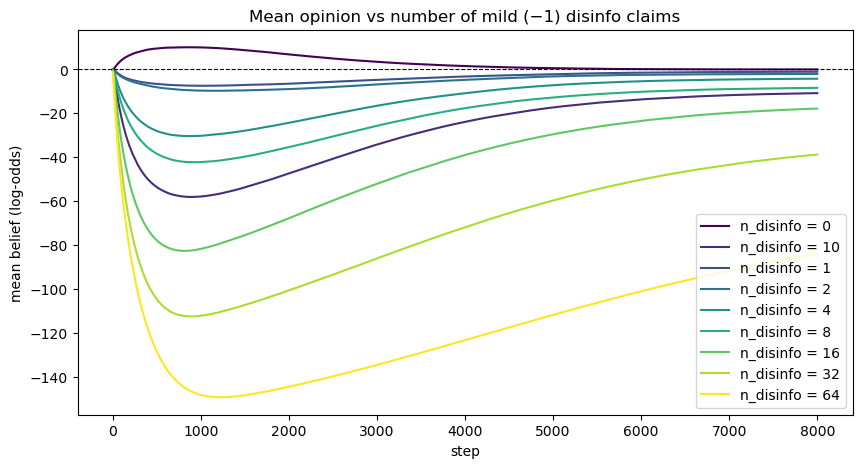

In [17]:
steps = np.arange(next(iter(mean_by_ndisinfo.values())).shape[1]) * base.record_every
colors = plt.cm.viridis(np.linspace(0, 1, len(n_disinfo_values_all)))

fig, ax = plt.subplots(figsize=(10, 5))
for nd, color in zip(n_disinfo_values_all, colors):
    ax.plot(steps, mean_by_ndisinfo[nd].mean(axis=0), color=color, lw=1.5, label=f"n_disinfo = {nd}")

ax.axhline(0.0, color="black", ls="--", lw=0.8)
ax.set_xlabel("step")
ax.set_ylabel("mean belief (log-odds)")
ax.set_title("Mean opinion vs number of mild (−1) disinfo claims")
ax.legend()
plt.show()

In [18]:
disinfo_mag_values = [0, -1, -2, -4, -8, -16, -32, -64]
n_runs = 20

mean_by_mag = {}
for mag in disinfo_mag_values:
    print(f"Running for disinfo_mag = {mag}")
    cfg = replace(base, n_disinfo=1, disinfo_mag=mag)
    results = [run(replace(cfg, seed=base.seed + r)) for r in range(n_runs)]
    mean_by_mag[mag] = np.stack([res.full_belief_traj.mean(axis=1) for res in results])

Running for disinfo_mag = 0
Running for disinfo_mag = -1
Running for disinfo_mag = -2
Running for disinfo_mag = -4
Running for disinfo_mag = -8
Running for disinfo_mag = -16
Running for disinfo_mag = -32
Running for disinfo_mag = -64


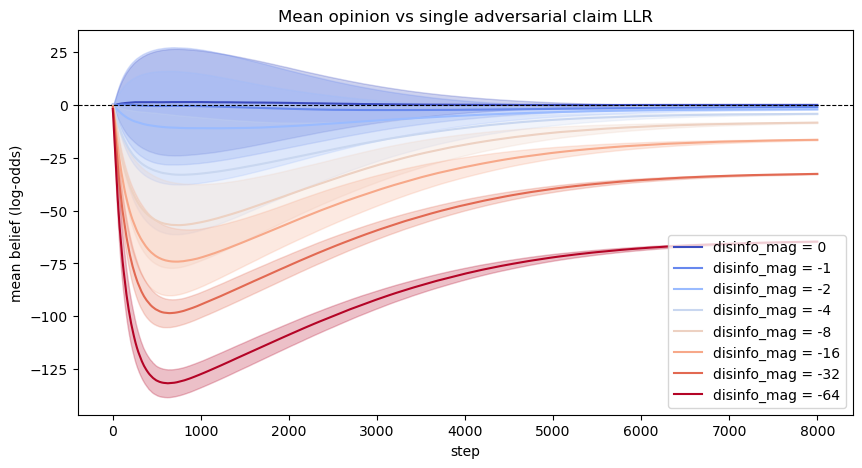

In [19]:
steps = np.arange(next(iter(mean_by_mag.values())).shape[1]) * base.record_every
colors = plt.cm.coolwarm(np.linspace(0, 1, len(disinfo_mag_values)))

fig, ax = plt.subplots(figsize=(10, 5))
for mag, color in zip(disinfo_mag_values, colors):
    traj = mean_by_mag[mag]          # (n_runs, n_records)
    mean = traj.mean(axis=0)
    std = traj.std(axis=0)
    ax.plot(steps, mean, color=color, lw=1.5, label=f"disinfo_mag = {mag}")
    ax.fill_between(steps, mean - std, mean + std, color=color, alpha=0.25)

ax.axhline(0.0, color="black", ls="--", lw=0.8)
ax.set_xlabel("step")
ax.set_ylabel("mean belief (log-odds)")
ax.set_title("Mean opinion vs single adversarial claim LLR")
ax.legend()
plt.show()

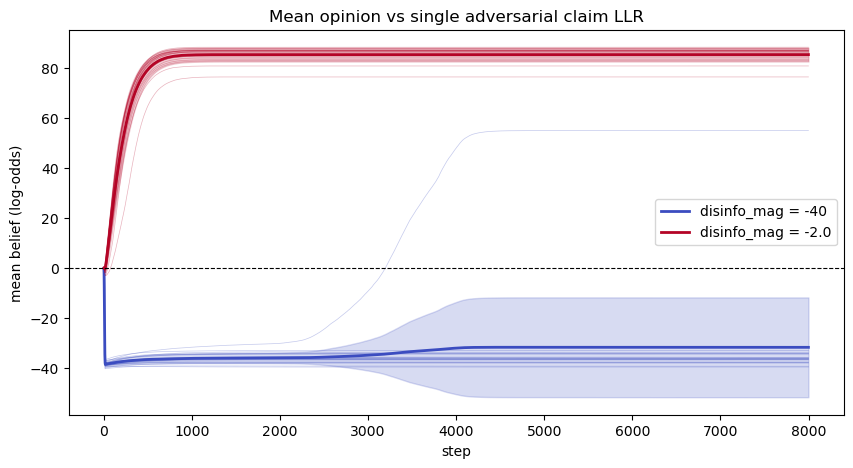

In [15]:
steps = np.arange(next(iter(mean_by_mag.values())).shape[1]) * base.record_every
colors = plt.cm.coolwarm(np.linspace(0, 1, len(disinfo_mag_values)))

fig, ax = plt.subplots(figsize=(10, 5))
for mag, color in zip(disinfo_mag_values, colors):
    traj = mean_by_mag[mag]          # (n_runs, n_records)
    mean = traj.mean(axis=0)
    std = traj.std(axis=0)

    for r in range(traj.shape[0]):
        ax.plot(steps, traj[r], color=color, lw=0.5, alpha=0.3)

    ax.plot(steps, mean, color=color, lw=2.0, label=f"disinfo_mag = {mag}")
    ax.fill_between(steps, mean - std, mean + std, color=color, alpha=0.20)

ax.axhline(0.0, color="black", ls="--", lw=0.8)
ax.set_xlabel("step")
ax.set_ylabel("mean belief (log-odds)")
ax.set_title("Mean opinion vs single adversarial claim LLR")
ax.legend()
plt.show()

[  1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
   1.   1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.
  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.
  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.
  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.
  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.
  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.
  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.
  -1. 

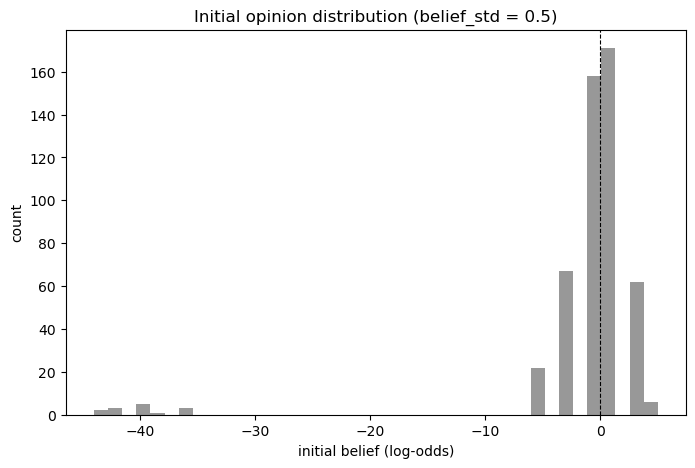

In [21]:
from rankers.agents import Agents
from rankers.claims import build_claims

cfg = replace(base, n_disinfo=1, disinfo_mag=-40.0)
rng = np.random.default_rng(cfg.seed)

# reproduce run()'s setup order exactly so the RNG state matches
from rankers.network import build_network, build_neighbor_table
g, flat, offsets = build_network(cfg)
build_neighbor_table(flat, offsets, cfg.n)
llr = build_claims(cfg, rng)
print(llr)


agents = Agents(cfg, rng, llr)

initial = agents.beliefs.copy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(initial, bins=40, color="tab:gray", alpha=0.8)
ax.axvline(0.0, color="black", ls="--", lw=0.8)
ax.set_xlabel("initial belief (log-odds)")
ax.set_ylabel("count")
ax.set_title(f"Initial opinion distribution (belief_std = {cfg.belief_std})")
plt.show()

In [17]:
llr = build_claims(cfg, rng)

print(llr)

[ 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -2.]


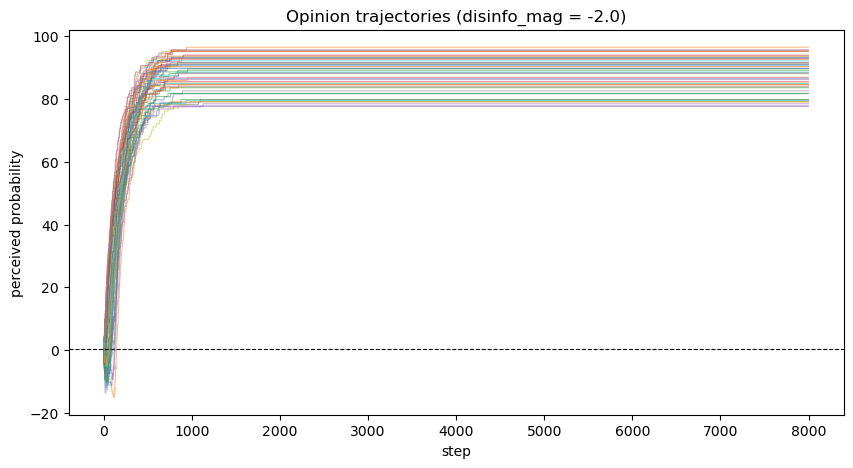

In [13]:
# plot per-agent opinion trajectories for one disinfo_mag
mag = -2.0
res = results[0]   # or rerun: res = run(replace(base, n_disinfo=1, disinfo_mag=mag, seed=base.seed))

steps = np.arange(res.belief_trajectories.shape[0]) * res.cfg.record_every
probabilities = 1.0 / (1.0 + np.exp(-res.belief_trajectories))

fig, ax = plt.subplots(figsize=(10, 5))
for k in range(res.cfg.n_tracked):
    ax.plot(steps, res.belief_trajectories[:, k], lw=0.8, alpha=0.5)
ax.set_ylabel("belief (log-odds)")
# drop set_ylim and the 0.5 axhline; use axhline(0.0) instead

ax.axhline(0.5, color="black", lw=0.8, ls="--")

ax.set_xlabel("step")
ax.set_ylabel("perceived probability")
ax.set_title(f"Opinion trajectories (disinfo_mag = {mag})")
plt.show()

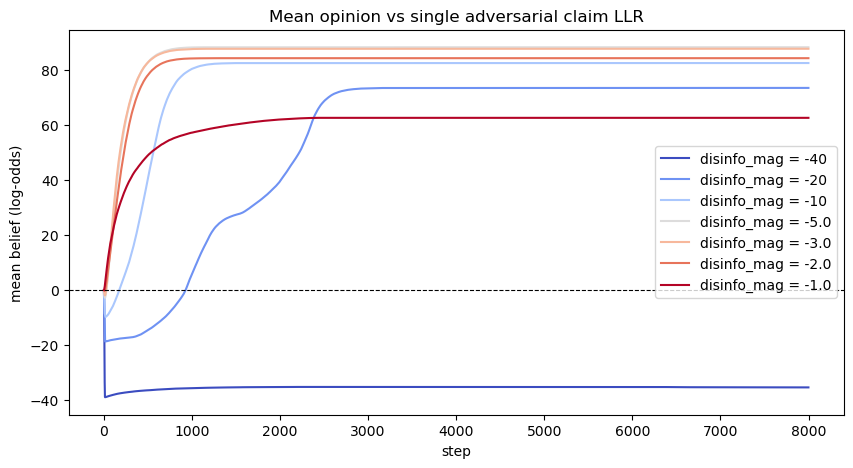

In [4]:
steps = np.arange(next(iter(mean_by_mag.values())).shape[1]) * base.record_every
colors = plt.cm.coolwarm(np.linspace(0, 1, len(disinfo_mag_values)))

fig, ax = plt.subplots(figsize=(10, 5))
for mag, color in zip(disinfo_mag_values, colors):
    ax.plot(steps, mean_by_mag[mag].mean(axis=0), color=color, lw=1.5, label=f"disinfo_mag = {mag}")

ax.axhline(0.0, color="black", ls="--", lw=0.8)
ax.set_xlabel("step")
ax.set_ylabel("mean belief (log-odds)")
ax.set_title("Mean opinion vs single adversarial claim LLR")
ax.legend()
plt.show()